In [ ]:
import matplotlib.pyplot as plt
import torch
from flashinfer_pipeline import Engine
from torch.profiler import profile, ProfilerActivity, record_function
%matplotlib inline
%env CUDA_AVAILABLE_DEVICES=5
engine = Engine()

/local1/jrl712/cse554-winter-2026/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>>> starting batched generation (128 rounds)


prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting ba

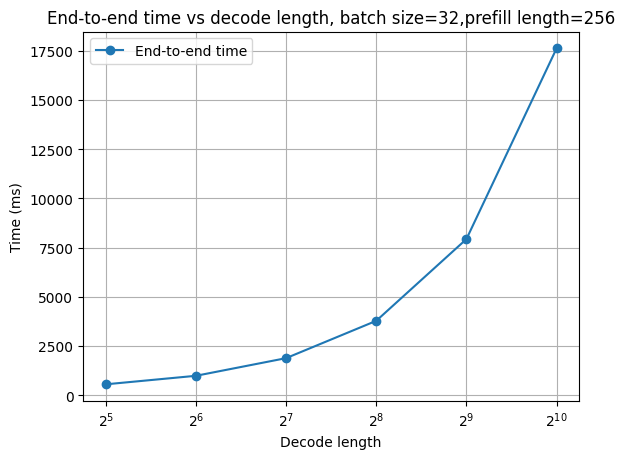

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [3]:
prefill_len = 256
decode_lens = [2**n for n in range(5,11)]
batch_size = 32
prompts = [
    "q" * prefill_len
    for _ in range(batch_size)
]
prefill_times = []
decode_times = []
##warmup
for _ in range(10):
    engine.generate_batched(prompts, rounds=128, time=True)
 
for decode_len in decode_lens:
    generated_texts, prefill_time, decode_time = engine.generate_batched(prompts, rounds=decode_len, time=True)
    prefill_times.append(prefill_time)
    decode_times.append(decode_time)

# log_decode_lens = [math.log2(d) for d in decode_lens]
plt.title(f"End-to-end time vs decode length, batch size=32,prefill length=256")
plt.semilogx(decode_lens, [p+d for p,d in zip(prefill_times, decode_times)], base=2, label="End-to-end time", marker='o')
plt.xlabel("Decode length")
plt.ylabel("Time (ms)")
plt.grid(True, which='both')
plt.legend()
plt.show()
plt.figure()
# plt.semilogx(decode_lens, decode_times, base=2, label="Decode time", color="orange", marker='o')
# plt.xlabel("Decode length")
# plt.ylabel("Time (ms)")
# plt.grid(True, which='both')
# plt.legend()
# plt.show()


    


>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appe

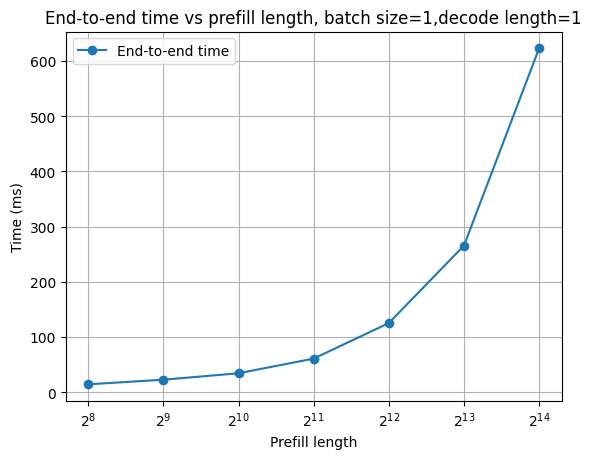

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
prefill_lens = [2**n for n in range(8,15)]
decode_len = 1
batch_size = 1

prefill_times = []
decode_times = []
##warmup
prompts = [
    "q" * prefill_len[0]
    for _ in range(batch_size)
]
for _ in range(10):
    engine.generate_batched(prompts, rounds=128, time=True)
 
for prefill_len in prefill_lens:
    prompts = [
        "q" * prefill_len
        for _ in range(batch_size)
    ]
    generated_texts, prefill_time, decode_time = engine.generate_batched(prompts, rounds=decode_len, time=True)
    prefill_times.append(prefill_time)
    decode_times.append(decode_time)

# log_decode_lens = [math.log2(d) for d in decode_lens]
plt.title("End-to-end time vs prefill length, batch size=1,decode length=1")
plt.semilogx(prefill_lens, [p+d for p,d in zip(prefill_times, decode_times)], base=2, label="End-to-end time", marker='o')
plt.xlabel("Prefill length")
plt.ylabel("Time (ms)")
plt.grid(True, which='both')
plt.legend()
plt.show()
plt.figure()
# plt.semilogx(decode_lens, decode_times, base=2, label="Decode time", color="orange", marker='o')
# plt.xlabel("Decode length")
# plt.ylabel("Time (ms)")
# plt.grid(True, which='both')
# plt.legend()
# plt.show()


    


>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appe

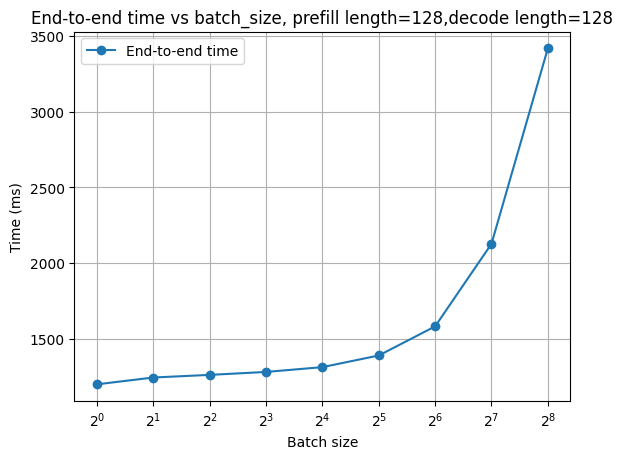

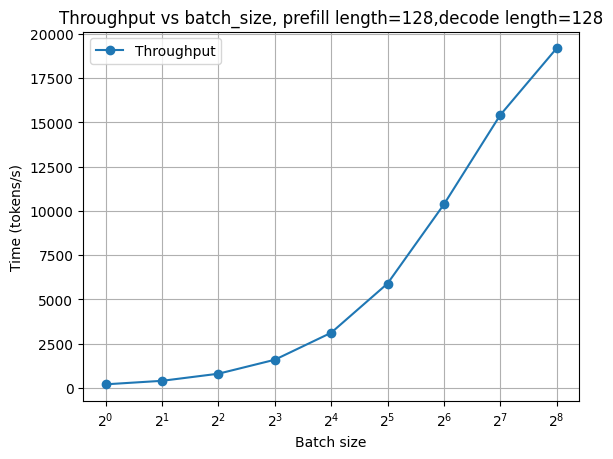

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [3]:
prefill_len = 128
decode_len = 128
batch_sizes = [2**n for n in range(0,9)]

prefill_times = []
decode_times = []
##warmup
prompts = [
    "q" * prefill_len
    for _ in range(batch_sizes[3])
]
for _ in range(10):
    engine.generate_batched(prompts, rounds=128, time=True)
 
for batch_size in batch_sizes:
    prompts = [
        "q" * prefill_len
        for _ in range(batch_size)
    ]
    generated_texts, prefill_time, decode_time = engine.generate_batched(prompts, rounds=decode_len, time=True)
    prefill_times.append(prefill_time)
    decode_times.append(decode_time)

# log_decode_lens = [math.log2(d) for d in decode_lens]
plt.title("End-to-end time vs batch_size, prefill length=128,decode length=128")
plt.semilogx(batch_sizes, [p+d for p,d in zip(prefill_times, decode_times)], base=2, label="End-to-end time", marker='o')
plt.xlabel("Batch size")
plt.ylabel("Time (ms)")
plt.grid(True, which='both')
plt.legend()
plt.show()
plt.figure()

throughput = [(prefill_len + decode_len)*b / ((p+d)/1000) for p,d,b in zip(prefill_times, decode_times, batch_sizes)]
plt.title("Throughput vs batch_size, prefill length=128,decode length=128")
plt.semilogx(batch_sizes, throughput, base=2, label="Throughput", marker='o')
plt.xlabel("Batch size")
plt.ylabel("Time (tokens/s)")
plt.grid(True, which='both')
plt.legend()
plt.show()
plt.figure()
# plt.semilogx(decode_lens, decode_times, base=2, label="Decode time", color="orange", marker='o')
# plt.xlabel("Decode length")
# plt.ylabel("Time (ms)")
# plt.grid(True, which='both')
# plt.legend()
# plt.show()


    


In [2]:
prefill_len = 256
decode_lens = [2**n for n in range(5,11)]
batch_size = 32
prompts = [
    "q" * prefill_len
    for _ in range(batch_size)
]
prefill_times = []
decode_times = []
##warmup
for _ in range(10):
    engine.generate_batched(prompts, rounds=128, time=True)
 

with profile(activities=[ProfilerActivity.CUDA], with_stack=True, experimental_config=torch._C._profiler._ExperimentalConfig(verbose=True),) as prof:
    with record_function("run"):
        for decode_len in decode_lens:
            generated_texts, prefill_time, decode_time = engine.generate_batched(prompts, rounds=decode_len, time=True)
            prefill_times.append(prefill_time)
            decode_times.append(decode_time)



    


>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
>>> starting batched generation (128 rounds)
prefill pass finished - appe

In [4]:
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10, max_name_column_width=1000))

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------  ------------  ------------  ------------ 

In [5]:
print(prof.key_averages(group_by_stack_n=5).table(sort_by="cuda_time_total", row_limit=2, max_name_column_width=1000))

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------  ------------  ------------  ------------ 

In [6]:
prof.export_chrome_trace("trace.json")

In [2]:
prefill_len = 256
decode_lens = [2**n for n in range(5,11)]
batch_size = 32
prompts = [
    "q" * prefill_len
    for _ in range(batch_size)
]
prefill_times = []
decode_times = []
##warmup
for _ in range(10):
    engine.generate_batched(prompts, rounds=128, time=True)
 


for decode_len in decode_lens:
    generated_texts, prefill_time, decode_time = engine.generate_batched(prompts, rounds=decode_len, time=True)
    prefill_times.append(prefill_time)
    decode_times.append(decode_time)

>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
Last decode cycle profile, rounds= 128
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
prefill_lens = [2**n for n in range(8,15)]
decode_len = 1
batch_size = 1

prefill_times = []
decode_times = []
##warmup
prompts = [
    "q" * prefill_lens[0]
    for _ in range(batch_size)
]
for _ in range(10):
    engine.generate_batched(prompts, rounds=128, time=True)

for prefill_len in prefill_lens:
    with profile(activities=[ProfilerActivity.CUDA], with_stack=True, experimental_config=torch._C._profiler._ExperimentalConfig(verbose=True),) as prof:
        with record_function("run"):
            prompts = [
                "q" * prefill_len
                for _ in range(batch_size)
            ]
            generated_texts, prefill_time, decode_time = engine.generate_batched(prompts, rounds=decode_len, time=True)
            prefill_times.append(prefill_time)
            decode_times.append(decode_time)
    print("----Prefill length=", prefill_len, "----")
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10, max_name_column_width=200))

>>> starting batched generation (128 rounds)
prefill pass finished - appending first generated token …
Last decode cycle profile, rounds= 128
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------